Dataset shape: (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Item matrix shape: (9742, 25)


,userId,movieIdx,rating
0,0,7270,5
1,0,860,4
2,0,5390,1
3,0,5191,1
4,0,5734,3


Utility matrix shape: (200, 9742)

Content-based recommendations:
[('Antz', np.float64(0.9998791701103789)), ('Toy Story 2', np.float64(0.9997869946574376)), ('Adventures of Rocky and Bullwinkle, The', np.float64(0.9996699742403703)), ("Emperor's New Groove, The", np.float64(0.9996699742403703)), ('Monsters, Inc.', np.float64(0.9995287551543786))]

Collaborative recommendations:
[('Millennium Actress (Sennen joyû)', np.float64(3.232889373683886)), ('Anne of Green Gables', np.float64(3.1988534565792563)), ('Sweet Liberty', np.float64(3.1988534565792563)), ('X-Men Origins: Wolverine', np.float64(3.1988534565792563)), ('Rock of Ages', np.float64(3.1988534565792563))]

Hybrid recommendations:
[('Millennium Actress (Sennen joyû)', np.float64(0.7825301258184449)), ('Grown Ups 2', np.float64(0.7370304021343959)), ('Sweet Liberty', np.float64(0.7158127055736851)), ('Rock of Ages', np.float64(0.6866817467608802)), ('Exterminating Angel, The (Ángel exterminador, El)', np.float64(0.68543471490474

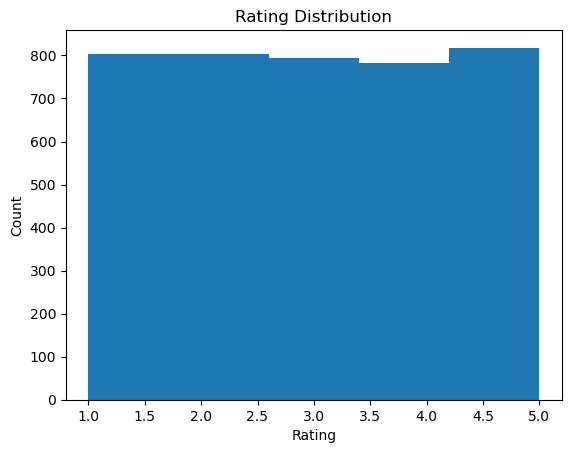


SUMMARY:
CBF  -> Uses movie features
CF   -> Uses user behavior
Hybrid -> Combines both for better accuracy


In [1]:
# ==========================================
# HYBRID MOVIE RECOMMENDER SYSTEM
# (Clean + Explained Version)
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

# ------------------------------------------
# 1. LOAD DATA
# ------------------------------------------
movies = pd.read_csv("movies.csv")

print("Dataset shape:", movies.shape)
display(movies.head())

# ------------------------------------------
# 2. FEATURE ENGINEERING
# ------------------------------------------

# Extract year
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)").astype(float)

# Clean title
movies["clean_title"] = movies["title"].str.replace(r"\s*\(\d{4}\)", "", regex=True)

# Clean genres
movies["genres"] = movies["genres"].fillna("")
movies["genres_text"] = movies["genres"].str.replace("|", " ", regex=False)

# ------------------------------------------
# 3. TF-IDF (CONTENT FEATURES)
# ------------------------------------------
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies["genres_text"])

# Add year as feature
scaler = MinMaxScaler()
year_scaled = scaler.fit_transform(movies[["year"]].fillna(2000))

# Combine features
ITEM_MATRIX = np.hstack([tfidf_matrix.toarray(), year_scaled])

print("Item matrix shape:", ITEM_MATRIX.shape)

# ------------------------------------------
# 4. SIMULATE USER RATINGS
# ------------------------------------------
np.random.seed(42)

N_USERS = 200
N_MOVIES = len(movies)

ratings = []

for user in range(N_USERS):
    for movie in np.random.choice(N_MOVIES, size=20):
        rating = np.random.randint(1, 6)
        ratings.append([user, movie, rating])

ratings_df = pd.DataFrame(ratings, columns=["userId", "movieIdx", "rating"])

display(ratings_df.head())

# ------------------------------------------
# 5. CREATE USER-ITEM MATRIX
# ------------------------------------------
R = np.zeros((N_USERS, N_MOVIES))

for _, row in ratings_df.iterrows():
    R[int(row["userId"]), int(row["movieIdx"])] = row["rating"]

print("Utility matrix shape:", R.shape)

# ------------------------------------------
# 6. COLLABORATIVE FILTERING (SVD)
# ------------------------------------------
user_means = np.true_divide(R.sum(axis=1), (R > 0).sum(axis=1).clip(1))

R_centered = R.copy()
for i in range(N_USERS):
    mask = R[i] > 0
    R_centered[i, mask] -= user_means[i]

# Apply SVD
U, sigma, Vt = svds(csr_matrix(R_centered), k=20)
sigma = np.diag(sigma)

R_pred = np.clip(U @ sigma @ Vt + user_means[:, None], 1, 5)

# ------------------------------------------
# 7. CONTENT-BASED FILTERING
# ------------------------------------------
ITEM_SIM = cosine_similarity(ITEM_MATRIX)

def recommend_content(movie_idx, n=5):
    scores = list(enumerate(ITEM_SIM[movie_idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:n+1]

    return [(movies.iloc[i]["clean_title"], score) for i, score in scores]

# Example
print("\nContent-based recommendations:")
print(recommend_content(0))

# ------------------------------------------
# 8. CF RECOMMENDER
# ------------------------------------------
def recommend_cf(user_id, n=5):
    preds = R_pred[user_id]
    seen = set(np.where(R[user_id] > 0)[0])

    recs = [(i, preds[i]) for i in range(len(preds)) if i not in seen]
    recs = sorted(recs, key=lambda x: x[1], reverse=True)[:n]

    return [(movies.iloc[i]["clean_title"], score) for i, score in recs]

print("\nCollaborative recommendations:")
print(recommend_cf(0))

# ------------------------------------------
# 9. HYBRID RECOMMENDER
# ------------------------------------------
def recommend_hybrid(user_id, alpha=0.5, n=5):
    cf_scores = R_pred[user_id]
    
    # Content profile (average liked movies)
    liked = ratings_df[(ratings_df["userId"] == user_id) & (ratings_df["rating"] >= 4)]
    
    if len(liked) == 0:
        content_scores = np.zeros(N_MOVIES)
    else:
        content_scores = ITEM_SIM[liked["movieIdx"]].mean(axis=0)

    # Normalize
    cf_scores = (cf_scores - cf_scores.min()) / (cf_scores.max() - cf_scores.min() + 1e-9)

    final_scores = alpha * content_scores + (1 - alpha) * cf_scores

    seen = set(np.where(R[user_id] > 0)[0])
    recs = [(i, final_scores[i]) for i in range(N_MOVIES) if i not in seen]

    recs = sorted(recs, key=lambda x: x[1], reverse=True)[:n]

    return [(movies.iloc[i]["clean_title"], score) for i, score in recs]

print("\nHybrid recommendations:")
print(recommend_hybrid(0))

# ------------------------------------------
# 10. EVALUATION
# ------------------------------------------
mask = R > 0
rmse = np.sqrt(mean_squared_error(R[mask], R_pred[mask]))

print("\nRMSE:", rmse)

# ------------------------------------------
# 11. VISUALIZATION
# ------------------------------------------
plt.hist(ratings_df["rating"], bins=5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# ------------------------------------------
# 12. SUMMARY
# ------------------------------------------
print("\nSUMMARY:")
print("CBF  -> Uses movie features")
print("CF   -> Uses user behavior")
print("Hybrid -> Combines both for better accuracy")